In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import omicverse as ov

os.chdir('E:\\硕士\\bioinformatics\\GEO single cell\\GSE180928')

f:\Anaconda\envs\omicverse\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
ov.plot_set(font_path='Arial')

# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

ov.settings.cpu_gpu_mixed_init()

f:\Anaconda\envs\omicverse\Lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
Using already downloaded Arial font from: C:\Users\57630\AppData\Local\Temp\omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA GeForce RTX 4070
      Memory: 12.0 GB | Compute: 8.9

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated
Available GPU accelerators: CUDA


In [3]:
adata = sc.read_h5ad('GSE180928_processed.h5ad')

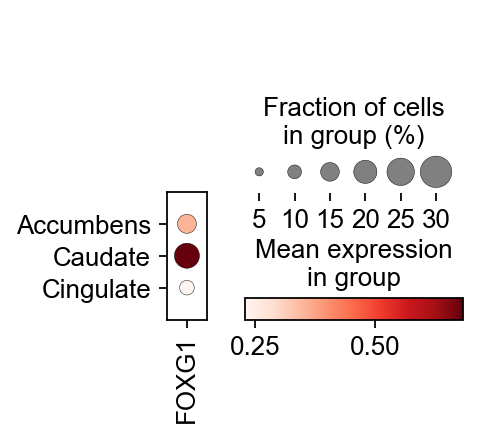

In [5]:
sc.pl.dotplot(adata,var_names=['FOXG1'], groupby='Location',save='FOXG1_Location_dotplot.pdf')

In [6]:
adata = adata[adata.obs['Location'] == 'Caudate']

In [9]:
print(adata.layers['counts'].max())
print(adata.X.max())

17043.0
7.060691



╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 5.0346s                                                 │
│  Shape:    28,801 x 17,120 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
🚀 Using GPU to calculate PCA...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 4070
    ||||||||---------------------- 3488/12282 MiB (28.4%)
computing PCA🔍
    with n_comps=50

Using CUDA device: NVIDIA GeForce RTX 4070
✅ Using built-in torch_pca for GPU-accelerated PCA
   🚀 Using torch_pca PCA for CUDA GPU acceleration
   🚀 torch_pca PCA backend: CUDA GPU acceleration (supports sparse matrices)
   📊 PCA input data type: ArrayView, shape: (28801, 3000), dtype: float32
   🔧 solver_used_i

Harmony converged after 5 iterations:  40%|████      | 4/10 [00:01<00:02,  2.76it/s]



✅ Harmony converged after 5 iterations

╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 4.1866s                                                 │
│  Shape:    28,801 x 17,120 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
🚀 Using torch CPU/GPU mixed mode to calculate neighbors...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 4070
    |||||||||||------------------- 4550/12282 MiB (37.0%)
🚀 Mixed mode default transformer: pyg

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu-gpu-mixed
   Neighbors: 15
   Method: torch
   Metric: euclidean
   Transformer: pyg
   Representation: X_pca_harmony
   🔍 Computing neighbor distances...
   💡 Using PyTorch Geometric KNN o

Training:  25%|██▌       | 1/4 [00:05<00:16]

✓ New best loss: 0.1735


...

✓ New best loss: 0.1559


Training:  75%|███████▌  | 3/4 [00:16<00:05]

✓ New best loss: 0.1538


Training: 100%|██████████| 4/4 [00:22<00:00]


✓ New best loss: 0.1530

────────────────────────────────────────────────────────────
✅ Training Completed!
📉 Final best loss: 0.1530

   💡 Using Parametric UMAP (PyTorch) on cuda

✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 28,801 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 22.5501s                                                │
│  Shape:    28,801 x 17,120 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


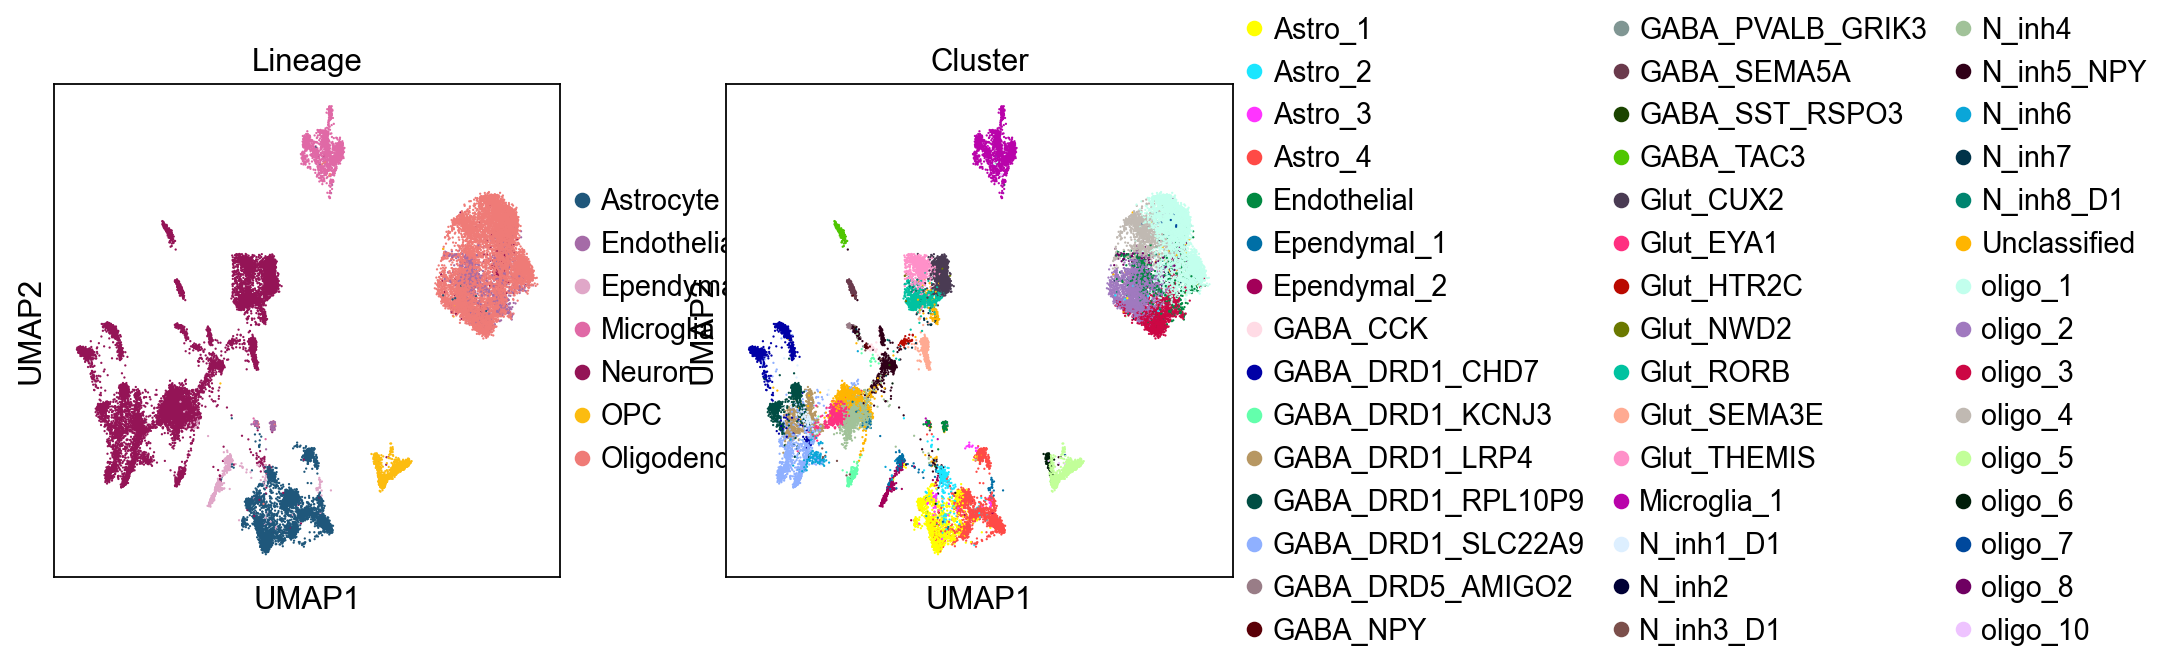

In [7]:
adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key="batch")
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)
ov.single.batch_correction(
    adata,batch_key='batch',
    methods='harmony',n_pcs=50
)
ov.pp.neighbors(adata, 
               use_rep='X_pca_harmony')
ov.pp.umap(adata)
sc.pl.umap(adata, color=['Lineage','Cluster'])

In [31]:
import pandas as pd

def merge_striatum_cluster(cluster):
    cluster = str(cluster)

    # 1. D1型纹状体棘状投射神经元
    if cluster.startswith("GABA_DRD1_"):
        return "SPN"

    if cluster in {
        "N_inh1_D1",
        "N_inh3_D1",
        "N_inh8_D1"
    }:
        return "SPN"

    # DRD5属于D1样受体，但不建议直接等同经典D1-SPN
    if cluster == "GABA_DRD5_AMIGO2":
        return "SPN"

    # 2. 纹状体中间神经元
    if cluster == "GABA_CCK":
        return "interneuron"

    if cluster in {"GABA_NPY", "N_inh5_NPY"}:
        return "interneuron"

    if cluster == "GABA_PVALB_GRIK3":
        return "interneuron"

    if cluster == "GABA_SST_RSPO3":
        return "interneuron"

    if cluster == "GABA_TAC3":
        return "interneuron"

    # 其余命名不明确的抑制性神经元
    if cluster.startswith("GABA_") or cluster.startswith("N_inh"):
        return "interneuron"

    # 3. 谷氨酸能神经元
    if cluster.startswith("Glut_"):
        return "interneuron"

    # 4. 非神经元
    if cluster.startswith("Astro_"):
        return "Astrocyte"

    if cluster.startswith("oligo_"):
        return "Oligodendrocyte"

    if cluster.startswith("Microglia_"):
        return "Microglia"

    if cluster == "Endothelial":
        return "Endothelial"

    if cluster.startswith("Ependymal_"):
        return "Ependymal"

    return "Unclassified"


# 假设AnnData对象叫adata，原始注释列叫Cluster
adata.obs["celltype"] = (
    adata.obs["Cluster"]
    .astype(str)
    .map(merge_striatum_cluster)
)

# 图中的OPC无法从右侧Cluster名称直接识别，
# 如果adata中存在Lineage列，可用它补回来
if "Lineage" in adata.obs.columns:
    opc_mask = adata.obs["Lineage"].astype(str).eq("OPC")
    adata.obs.loc[opc_mask, "celltype"] = "OPC"

adata.obs["celltype"] = (
    adata.obs["celltype"].astype("category")
)

print(pd.crosstab(
    adata.obs["Cluster"],
    adata.obs["celltype"]
))

celltype           Astrocyte  Endothelial  Ependymal  Microglia  OPC  \
Cluster                                                                
Astro_1                 1507            0          0          0    0   
Astro_2                  351            0          0          0    0   
Astro_3                   64            0          0          0    0   
Astro_4                 2084            0          0          0    0   
Endothelial                0          853          0          0    0   
Ependymal_1                0            0        194          0    0   
Ependymal_2                0            0        368          0    0   
GABA_CCK                   0            0          0          0    0   
GABA_DRD1_CHD7             0            0          0          0    0   
GABA_DRD1_KCNJ3            0            0          0          0    0   
GABA_DRD1_LRP4             0            0          0          0    0   
GABA_DRD1_RPL10P9          0            0          0          0 

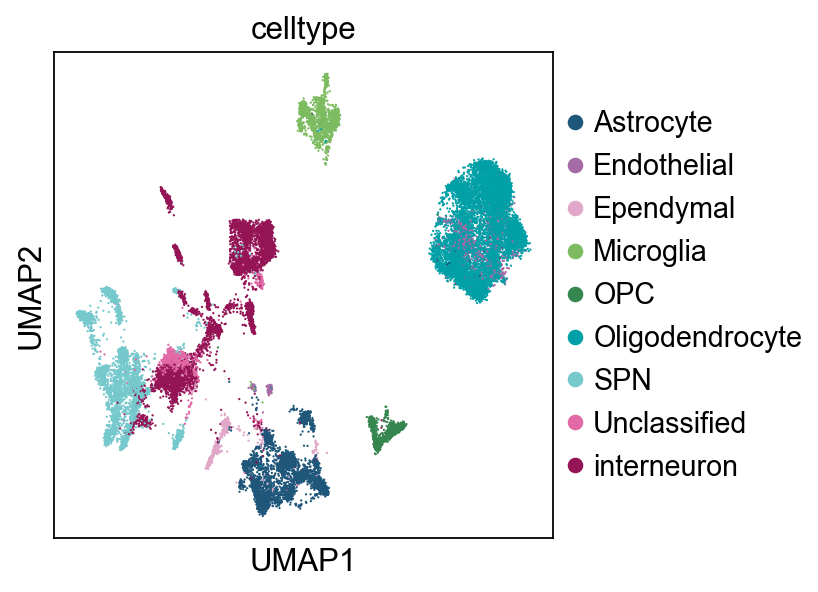

In [37]:
sc.pl.umap(adata, color=['celltype',],
           palette=ov.pl.sc_color[:9]
           )

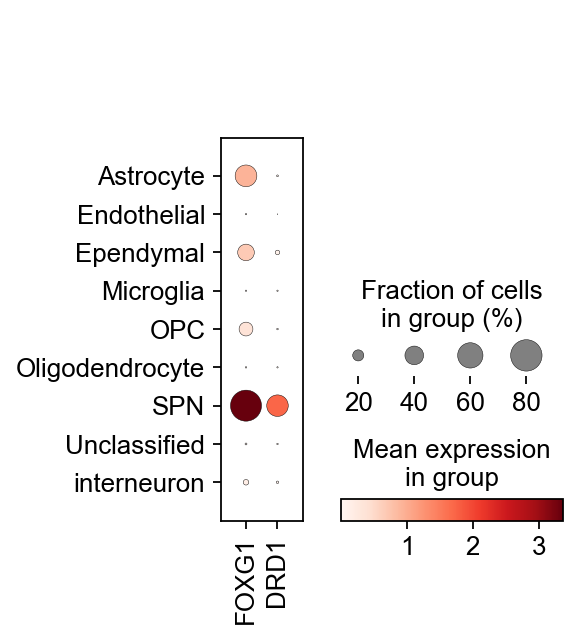

In [38]:
sc.pl.dotplot(adata,var_names=['FOXG1','DRD1',], groupby='celltype',save='caudate_FOXG1_celltype_dotplot.pdf')

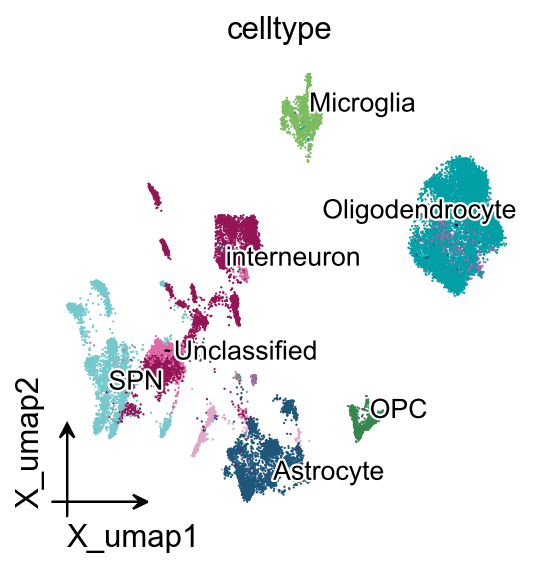

In [44]:
from matplotlib import patheffects
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,4))

ov.pl.embedding(
    adata,
    basis='X_umap',
    color=['celltype'],
    show=False, legend_loc=None, add_outline=False, 
    frameon='small',legend_fontoutline=2,ax=ax
)

ov.pl.embedding_adjust(
    adata,
    groupby='celltype',
    exclude=("Endothelial","Ependymal"),  
    basis='X_umap',
    ax=ax,
    adjust_kwargs=dict(arrowprops=dict(arrowstyle='-', color='black')),
    text_kwargs=dict(fontsize=12 ,#weight='bold',
                     path_effects=[patheffects.withStroke(linewidth=2, foreground='w')] ),
)
plt.savefig("caudate_umap.pdf")
ov.plt.show()

In [50]:
SPN=adata[adata.obs['celltype'] == 'SPN']
SPN.obs['sub'] = SPN.obs['Condition'].str[0:] + '_' + SPN.obs['celltype'].str[0:] 

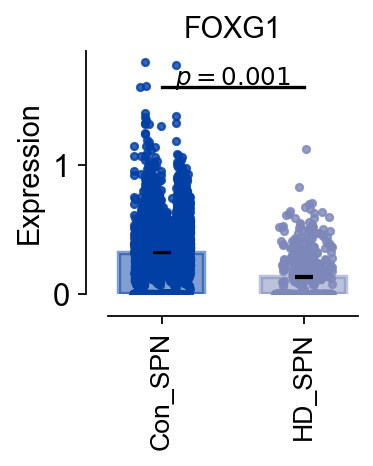

In [131]:
fig, ax = plt.subplots(figsize=(2,2))
ov.pl.bardotplot(SPN,groupby='sub',color='FOXG1',figsize=(6,2),
           ax=ax,
          ylabel='Expression',
           bar_kwargs={'alpha':0.5,'linewidth':2,'width':0.6,'capsize':4},
           scatter_kwargs={'alpha':0.8,'s':10,'marker':'o'})

ov.pl.add_palue(ax,line_x1=0,line_x2=1,line_y=1.6,
          text_y=0.02,
          text='$p={}$'.format(round(0.001,3)),
          fontsize=11,fontcolor='#000000',
             horizontalalignment='center',)
plt.savefig("caudate_FOXG1_SPN.pdf")

In [57]:
import decoupler as dc

In [72]:
db = dc.op.resource("MSigDB")
db

        genesymbol                          collection  \
                                                         
0             A1BG                   reactome_pathways   
1             A1BG               go_cellular_component   
2             A1BG  chemical_and_genetic_perturbations   
3             A1BG                         immunesigdb   
4             A1BG                         immunesigdb   
...            ...                                 ...   
5895457       ZZZ3                 mirna_targets_mirdb   
5895458       ZZZ3                 mirna_targets_mirdb   
5895459       ZZZ3                 mirna_targets_mirdb   
5895460       ZZZ3                     tf_targets_gtrf   
5895461       ZZZ3                 mirna_targets_mirdb   

                                                   geneset  
                                                            
0                                      REACTOME_HEMOSTASIS  
1                        GOCC_PLATELET_ALPHA_GRANULE_LUMEN  
2

In [73]:
db.collection.unique()

array(['reactome_pathways', 'go_cellular_component',
       'chemical_and_genetic_perturbations', 'immunesigdb',
       'tf_targets_legacy', 'cell_type_signatures',
       'go_biological_process', 'positional', 'mirna_targets_mirdb',
       'tf_targets_gtrf', 'cancer_modules', 'vaccine_response',
       'go_molecular_function', 'oncogenic_signatures',
       'cancer_cell_atlas', 'hallmark', 'pid_pathways', 'kegg_pathways',
       'human_phenotype_ontology', 'wikipathways',
       'cancer_gene_neighborhoods', 'mirna_targets_legacy',
       'biocarta_pathways', 'kegg_medicus_pathways'], dtype=object)

In [82]:
db_ = db[db.collection == 'kegg_pathways']

In [83]:
db_.rename(columns={'genesymbol': 'target', 'geneset': 'source',}, inplace=True)
db_ = db_.drop_duplicates(subset=['source', 'target'])

In [113]:
dc.mt.ulm(data=SPN, net=db_,tmin=3)
SPN.obsm["score_ulm"]

                            KEGG_ABC_TRANSPORTERS  \
TACGGGCCAGGCGATA-1-C5700Cd              -0.315063   
GCCAGCACAAATACGA-1-C5700Cd              -0.881711   
GACATCACAAGTGGGT-1-C5700Cd               0.164116   
TGTCCCACACACGCCA-1-C5700Cd               0.903634   
CAACCTCCACAGTCGC-1-C5700Cd              -0.467969   
...                                           ...   
TTCGCTGCAAGGCCTC-1-H5109Cd              -0.148988   
GGGCCATGTGATAGTA-1-H5109Cd              -0.808648   
ACACCAAAGGGATCGT-1-H5109Cd              -0.422815   
ATCATTCCAAGCACCC-1-H5109Cd               0.019275   
TGACAGTCACCCTGTT-1-H5109Cd              -1.009492   

                            KEGG_ACUTE_MYELOID_LEUKEMIA  \
TACGGGCCAGGCGATA-1-C5700Cd                     0.460587   
GCCAGCACAAATACGA-1-C5700Cd                     0.758214   
GACATCACAAGTGGGT-1-C5700Cd                     1.761553   
TGTCCCACACACGCCA-1-C5700Cd                     2.198329   
CAACCTCCACAGTCGC-1-C5700Cd                    -0.106678   
...      

In [114]:
scores = SPN.obsm["score_ulm"]
[x for x in scores.columns if "APOP" in x.upper()]

['KEGG_APOPTOSIS']

In [106]:
import scipy.sparse as sp
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [115]:
pathway = "KEGG_APOPTOSIS"
gene = "FOXG1"

# AUCell分数
auc = scores[pathway].reindex(SPN.obs_names)

# 目标基因表达量：确保X是log-normalized，而不是scale后的数据
x = SPN[:, gene].X
if sp.issparse(x):
    x = x.toarray()
expr = np.asarray(x).ravel()

df = SPN.obs.copy()
df["AUCell"] = auc
df["gene_expr"] = expr
df = df[["gene_expr", "AUCell"]].dropna()

In [116]:
rho, p = spearmanr(df["gene_expr"], df["AUCell"])

print(f"Spearman rho = {rho:.3f}")
print(f"P = {p:.3e}")

Spearman rho = -0.083
P = 9.730e-08


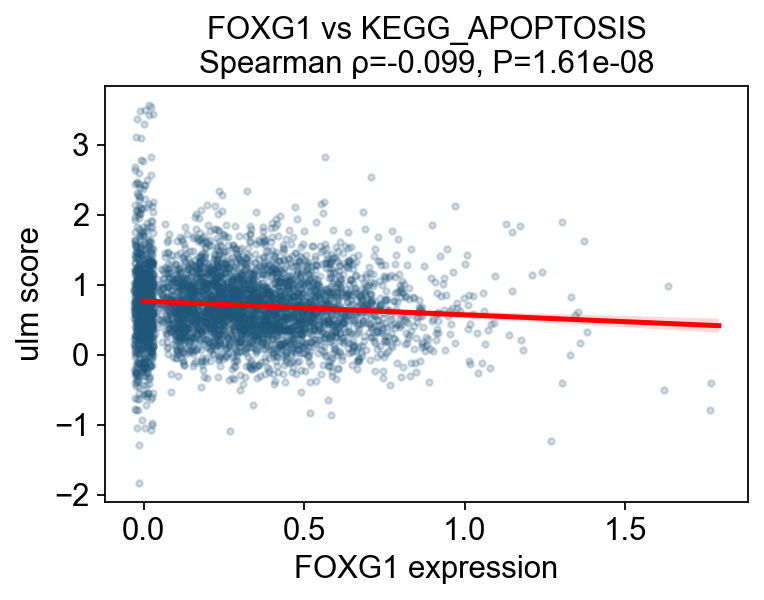

In [135]:
plt.figure(figsize=(5, 4))

sns.regplot(
    data=df,
    x="gene_expr",
    y="AUCell",
    x_jitter=0.03,
    scatter_kws={"s": 8, "alpha": 0.2},
    line_kws={"color": "red"}
)

plt.title(f"{gene} vs {pathway}\nSpearman ρ={rho:.3f}, P={p:.2e}")
plt.xlabel(f"{gene} expression")
plt.ylabel("ulm score")
plt.tight_layout()
plt.savefig(f"{gene} vs {pathway} Spearman.pdf")
plt.show()

In [118]:
# 仅分析目标基因被检测到的细胞
d = df[df["gene_expr"] > 0]
spearmanr(d["gene_expr"], d["AUCell"])

# 比较基因阳性与阴性细胞的通路分数
df.groupby(df["gene_expr"] > 0)["AUCell"].median()

gene_expr
False    0.738761
True     0.674619
Name: AUCell, dtype: float64

In [119]:
rho, p = spearmanr(d["gene_expr"], d["AUCell"])

print(f"Spearman rho = {rho:.3f}")
print(f"P = {p:.3e}")

Spearman rho = -0.099
P = 1.615e-08


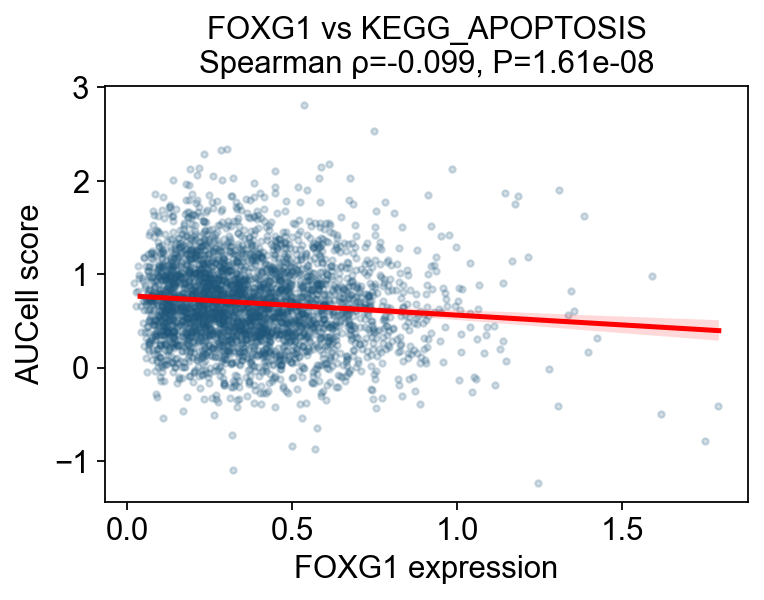

In [120]:
plt.figure(figsize=(5, 4))

sns.regplot(
    data=d,
    x="gene_expr",
    y="AUCell",
    x_jitter=0.03,
    scatter_kws={"s": 8, "alpha": 0.2},
    line_kws={"color": "red"}
)

plt.title(f"{gene} vs {pathway}\nSpearman ρ={rho:.3f}, P={p:.2e}")
plt.xlabel(f"{gene} expression")
plt.ylabel("ulm score")
plt.tight_layout()
plt.show()

In [122]:
fox_families = {
    "FOXG": ["FOXG1"],  # 放在最前面方便比较

    "FOXA": ["FOXA1", "FOXA2", "FOXA3"],
    "FOXB": ["FOXB1", "FOXB2"],
    "FOXC": ["FOXC1", "FOXC2"],
    "FOXD": [
        "FOXD1", "FOXD2", "FOXD3", "FOXD4",
        "FOXD4L1", "FOXD4L3", "FOXD4L4",
        "FOXD4L5", "FOXD4L6"
    ],
    "FOXE": ["FOXE1", "FOXE3"],
    "FOXF": ["FOXF1", "FOXF2"],
    "FOXH": ["FOXH1"],
    "FOXI": ["FOXI1", "FOXI2", "FOXI3"],
    "FOXJ": ["FOXJ1", "FOXJ2", "FOXJ3"],
    "FOXK": ["FOXK1", "FOXK2"],
    "FOXL": ["FOXL1", "FOXL2"],
    "FOXM": ["FOXM1"],
    "FOXN": ["FOXN1", "FOXN2", "FOXN3", "FOXN4"],
    "FOXO": ["FOXO1", "FOXO3", "FOXO4", "FOXO6"],
    "FOXP": ["FOXP1", "FOXP2", "FOXP3", "FOXP4"],
    "FOXQ": ["FOXQ1"],
    "FOXR": ["FOXR1", "FOXR2"],
    "FOXS": ["FOXS1"],
}

In [123]:

# 优先使用合并后的细胞类型
if "celltype" in adata.obs.columns:
    groupby = "celltype"
else:
    groupby = "Cluster"

# 只保留数据中实际存在的FOX基因
fox_present = {
    family: [g for g in genes if g in adata.var_names]
    for family, genes in fox_families.items()
}

fox_present = {
    family: genes
    for family, genes in fox_present.items()
    if len(genes) > 0
}

all_fox = [
    gene
    for genes in fox_families.values()
    for gene in genes
]

present = [g for g in all_fox if g in adata.var_names]
missing = [g for g in all_fox if g not in adata.var_names]

print(f"检测到 {len(present)}/49 个FOX基因")
print("不存在于数据中的基因：", missing)

检测到 17/49 个FOX基因
不存在于数据中的基因： ['FOXA1', 'FOXA2', 'FOXA3', 'FOXB1', 'FOXB2', 'FOXC1', 'FOXC2', 'FOXD1', 'FOXD2', 'FOXD3', 'FOXD4', 'FOXD4L1', 'FOXD4L4', 'FOXD4L5', 'FOXE1', 'FOXE3', 'FOXF1', 'FOXH1', 'FOXI1', 'FOXI2', 'FOXI3', 'FOXL1', 'FOXL2', 'FOXM1', 'FOXN1', 'FOXN4', 'FOXO6', 'FOXP3', 'FOXQ1', 'FOXR1', 'FOXR2', 'FOXS1']


In [ ]:
fox = adata[:, present].copy()

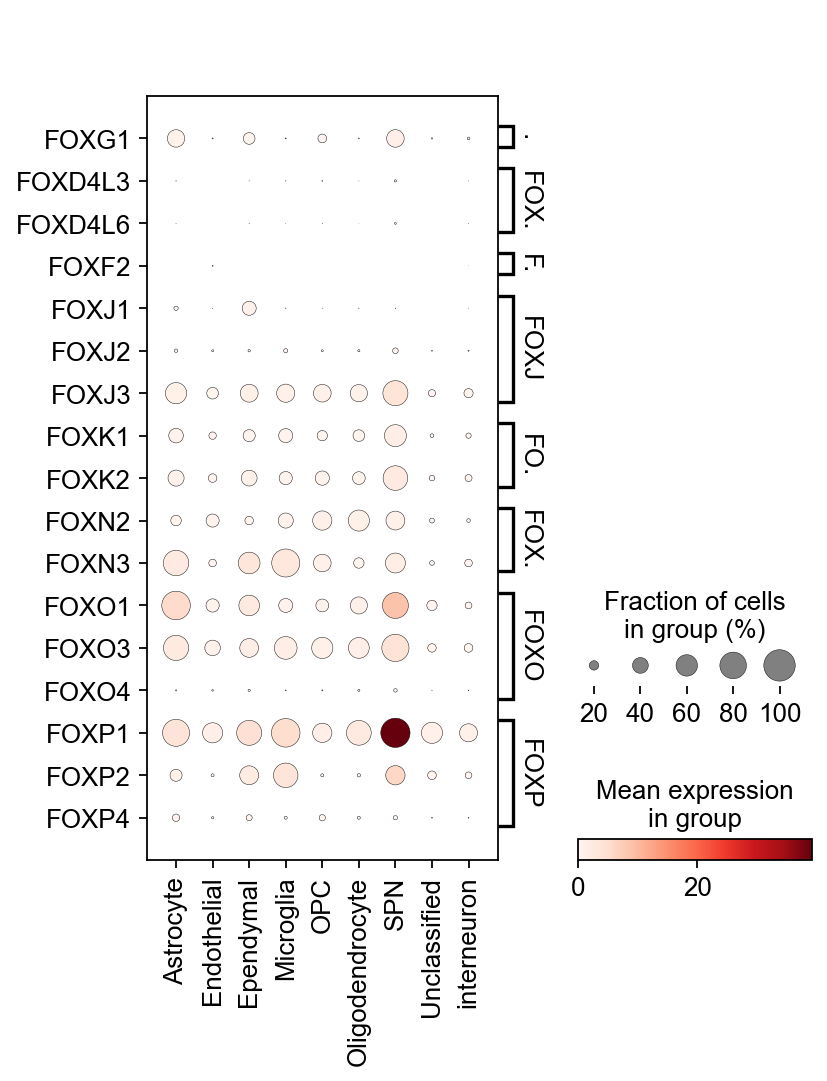

In [132]:
sc.pl.dotplot(
    adata[adata.obs['Condition']=='HD'],
    var_names=fox_present,
    groupby=groupby,

    # 每个基因在不同细胞类型间缩放到0–1
    # 适合观察FOXG1与其他FOX基因的细胞类型特异性
    #standard_scale="group",

    expression_cutoff=0,
    mean_only_expressed=False,
    cmap="Reds",
    #dot_min=0.01,
    #dot_max=0.8,
    swap_axes=True,
    #return_fig=True
)

In [133]:
adata.write_h5ad('caudate_m.h5ad')